# **Tecnicas de Manipulacion de Datos**

**Integrantes:**
- Gino Andrades
- Yai Selti
- Miguel Villarroel
                
**Correo Electrónico:**
- gi.andrades@duocuc.cl
- ya.selti@duocuc.cl
- mig.villarroel@duocuc.cl

**Fecha de Creación:** 03 Abril de 2026

**Versión:** 1.0


---


# **Descripción**
El actual problema de la empresa es la disminución  en la tasa de retención de sus clientes, lo que afecta directamente en los ingresos y los elevados costos en la adquisición de nuevos clientes.
El objetivo es generar una solución analítica que permita anticipar comportamiento y diseñar soluciones preventivas basadas en los datos, utilizando para ello diversas tecnologías en el análisis de datos que permiten procesar grandes volúmenes de información de manera eficiente.
    Z

---


# **Requisitos de Software**
Este notebook fue desarrollado con Python 3.12.

A continuación se listan las bibliotecas necesarias:

* pandas (>=1.1.0)
* matplotlib (3.7.1)
* numpy (2.0.2)
* seaborn (0.13.2)

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

In [545]:
import pandas as pd
print(pd.__version__)

2.2.2


**Importacion del Dataset a Operar** (No Limpio)

In [546]:
!wget https://raw.githubusercontent.com/Zevk4/Evaluacion_Parcial_1/refs/heads/main/data/dataset_clientes.csv

--2026-04-09 03:36:59--  https://raw.githubusercontent.com/Zevk4/Evaluacion_Parcial_1/refs/heads/main/data/dataset_clientes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3282843 (3.1M) [text/plain]
Saving to: ‘dataset_clientes.csv.9’

dataset_clientes.cs 100%[===================>]   3.13M  --.-KB/s    in 0.05s   

2026-04-09 03:36:59 (68.3 MB/s) - ‘dataset_clientes.csv.9’ saved [3282843/3282843]



Importaciones necesarias para llevar a cabo el proyecto

In [547]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder


In [548]:
# Carga el set de datos
data = pd.read_csv('dataset_clientes.csv')

In [549]:
data['ingreso_mensual'].isnull().sum()

np.int64(1021)

# Revisión del estado

In [550]:
# Cantidad de observaciones y columnas
data.shape

(20400, 22)

# Valores faltantes y tipos de datos

In [551]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu

In [552]:
data.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


# Existencia de duplicados

In [553]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(400)

# Saber Que registros son los Duplicados

In [554]:
# Obtiene los registos duplicados
data[data.duplicated(keep=False)].sort_values(by='id_cliente')

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
20032,178,2022-02-16,58,Otro,Centro,Soltero,574734.320058,124060.694605,1.567047e+06,706.773275,...,133,Alto,Premium,2,0,Tienda,Sabado,11,8146,1
177,178,2022-02-16,58,Otro,Centro,Soltero,574734.320058,124060.694605,1.567047e+06,706.773275,...,133,Alto,Premium,2,0,Tienda,Sabado,11,8146,1
215,216,2021-05-23,77,Femenino,Centro,Divorciado,696251.283767,755824.522948,2.522168e+06,691.380909,...,217,Alto,Estandar,5,1,App,Sabado,6,4541,1
20300,216,2021-05-23,77,Femenino,Centro,Divorciado,696251.283767,755824.522948,2.522168e+06,691.380909,...,217,Alto,Estandar,5,1,App,Sabado,6,4541,1
20348,327,2019-07-15,43,Femenino,Sur,Soltero,611018.691110,238932.156632,8.764364e+05,618.183493,...,303,Medio,Basico,3,0,App,Lunes,11,6291,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19921,19922,2020-01-22,52,Masculino,Sur,Casado,892522.042338,161697.180367,1.750559e+06,662.274443,...,274,Bajo,Premium,1,0,App,Viernes,3,4398,1
19923,19924,2018-01-17,54,Otro,Centro,Casado,822109.701169,489936.535727,2.022070e+06,584.830157,...,145,Bajo,Estandar,1,0,Tienda,Miercoles,17,8097,1
20289,19924,2018-01-17,54,Otro,Centro,Casado,822109.701169,489936.535727,2.022070e+06,584.830157,...,145,Bajo,Estandar,1,0,Tienda,Miercoles,17,8097,1
20147,19983,2022-02-17,26,Otro,Centro,Soltero,947809.404071,221838.916723,3.226056e+06,556.285263,...,361,Alto,Basico,1,1,Tienda,Jueves,5,6118,1


# Existencia de valores atípicos (outliers)

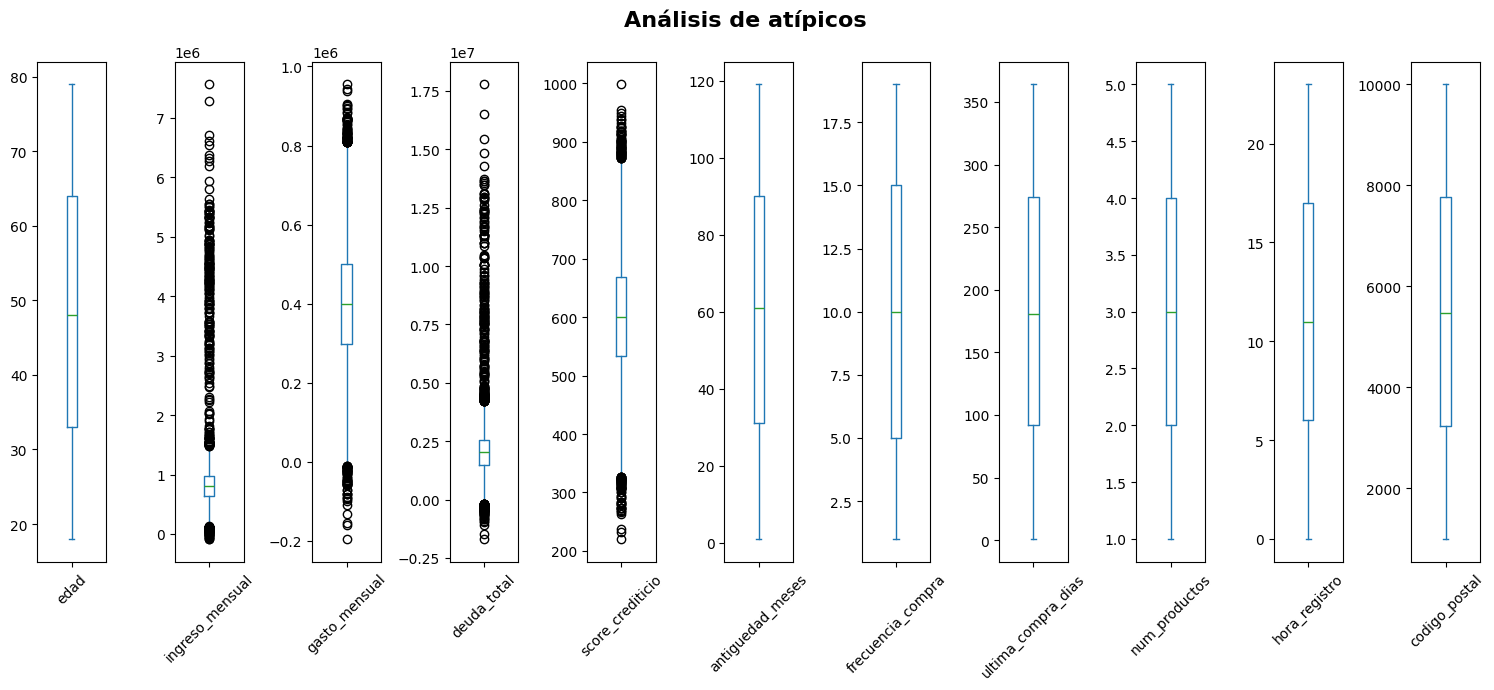

In [555]:
revision_atipicos = ['edad', 'ingreso_mensual', 'gasto_mensual',	'deuda_total', 'score_crediticio', 'antiguedad_meses', 'frecuencia_compra', 'ultima_compra_dias', 'num_productos', 'hora_registro', 'codigo_postal' ]
fig, axes = plt.subplots(1, 11 , figsize=(20,20))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(15,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

In [556]:
# Integra ambos pipelines
preprocesador = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

**Observaciones**:

**Boxplots (Outliers)**: El gráfico inicial nos muestra "bigotes" extremadamente largos.

# Estadísticas antes de la limpieza

**Nulos a TRATAR**

In [557]:
data['ingreso_mensual'].isnull().sum()

np.int64(1021)

In [558]:
data['gasto_mensual'].isnull().sum()

np.int64(1025)

In [559]:
data['score_crediticio'].isnull().sum()

np.int64(1021)

In [560]:
data['deuda_total'].isnull().sum()

np.int64(0)

**Negativos a TRATAR**

In [561]:
data['ingreso_mensual'].lt(0).sum()

np.int64(11)

In [562]:
data['gasto_mensual'].lt(0).sum()

np.int64(68)

In [563]:
data['deuda_total'].lt(0).sum()

np.int64(143)

In [564]:
data['score_crediticio'].lt(0).sum()

np.int64(0)

In [565]:
# Muestra las medidas estadísticas, descartando la columna "id_cliente"
data.drop(columns=['id_cliente']).describe()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,codigo_postal,abandono
count,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,0.501373,11.416716,5488.970147,0.396814
std,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,0.500010,6.891420,2602.374998,0.489249
min,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1000.000000,0.000000
25%,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,0.000000,6.000000,3239.000000,0.000000
50%,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,1.000000,11.000000,5477.500000,0.000000
75%,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,1.000000,17.000000,7775.000000,1.000000
max,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,1.000000,23.000000,9998.000000,1.000000


In [566]:
# Nos muestra todas las variables que son tipo object, nos ayudara a indentificar las variables cualitativas
data.describe(include="object")

,fecha_registro,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro
count,20400,20400,20400,20400,20400,20400,20400,20400
unique,2000,3,3,3,3,3,3,7
top,2022-04-09,Otro,Sur,Casado,Bajo,Estandar,App,Miercoles
freq,21,6997,6812,6828,6886,6878,6894,3000


Pequeña revisión de los datos almacenados en las variables cualitativas:
Revisamos todas las variables cualitativas del paso anterior; sin embargo, no encontramos incoherencias ni errores de tipeo. Para evitar que el documento sea demasiado extenso, solo detallaremos la variable **tipo_plan**, ya que trabajaremos con ella durante la fase de limpieza.

In [567]:
data.tipo_plan.unique()

array(['Estandar', 'Premium', 'Basico'], dtype=object)

**En este Apartado revisamos todos los ingresos con valores negativos**

In [568]:
# Filtramos el dataframe para mostrar los ingresos menores a 0
display(data.loc[data['ingreso_mensual'] < 0])

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
1162,1163,2019-01-21,75,Otro,Norte,Soltero,-16979.365127,302795.284089,2.496784e+06,698.986973,...,286,Alto,Premium,4,1,Web,Lunes,3,8326,1
2869,2870,2022-06-08,44,Masculino,Sur,Divorciado,-72801.371061,462607.688777,1.578514e+06,630.611126,...,283,Alto,Premium,1,0,Web,Sabado,10,4378,0
4636,4637,2022-07-17,30,Femenino,Centro,Divorciado,-5996.224236,418875.991508,2.555154e+06,529.922441,...,135,Alto,Estandar,4,1,Tienda,Martes,18,2136,0
7534,7535,2019-01-03,51,Otro,Centro,Divorciado,-5601.545909,582767.766351,2.088971e+06,720.393549,...,89,Medio,Premium,2,1,App,Sabado,2,5776,0
10888,10889,2023-01-16,66,Masculino,Norte,Divorciado,-49141.756364,100273.851856,1.508473e+06,716.991312,...,6,Bajo,Basico,2,1,Tienda,Miercoles,18,6590,0
12284,12285,2021-12-15,24,Femenino,Norte,Casado,-77497.373937,729446.600473,1.922807e+06,535.412910,...,61,Medio,Basico,1,1,Tienda,Lunes,23,3159,1
12946,12947,2018-05-21,47,Otro,Norte,Casado,-16148.451189,462264.106635,1.347525e+06,725.624925,...,200,Alto,Basico,3,1,Tienda,Viernes,18,7625,0
13254,13255,2019-12-23,29,Masculino,Sur,Soltero,-83025.771814,NaN,2.504461e+06,688.010914,...,125,Bajo,Premium,4,0,Tienda,Lunes,12,7826,1
14890,14891,2022-10-28,43,Masculino,Centro,Soltero,-48924.489820,365967.121712,1.829788e+06,541.471922,...,256,Alto,Estandar,4,0,Web,Lunes,21,5981,0
17423,17424,2018-05-23,73,Otro,Norte,Casado,-39130.772737,323714.648376,2.808960e+06,NaN,...,267,Alto,Basico,5,1,App,Miercoles,3,7417,0


# **Graficamos las Variables Cuantitativas antes de Su limpieza**

**Observaciones** :

* Histogramas (Ingreso/Deuda): En el estado actual, observamos picos artificiales en los extremos debido a datos mal cargados.

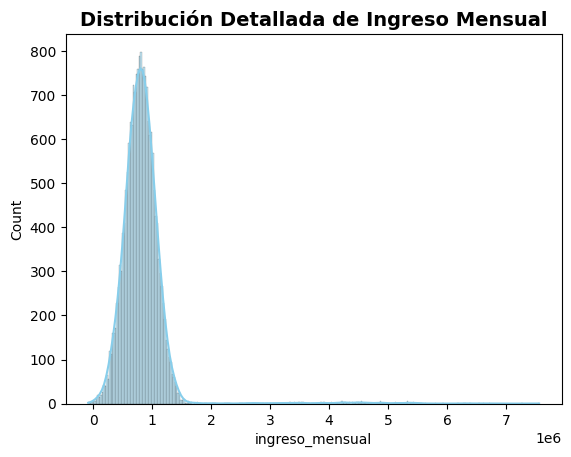

In [569]:
sns.histplot(data['ingreso_mensual'], kde=True, color="skyblue")
plt.title('Distribución Detallada de Ingreso Mensual', fontsize=14, fontweight="bold")
plt.show()

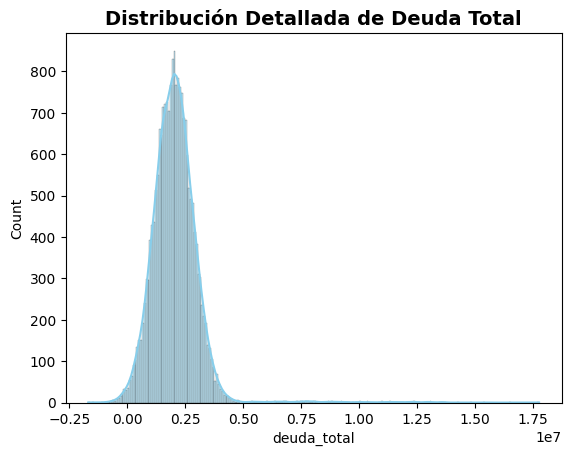

In [570]:
sns.histplot(data['deuda_total'], kde=True, color="skyblue")
plt.title('Distribución Detallada de Deuda Total', fontsize=14, fontweight="bold")
plt.show()

# Fase 1: Limpieza de Datos

Para garantizar la integridad del modelo, se desarrollaron transformadores personalizados (GroupedImputer y NegativeToNull) basados en las siguientes premisas:

* Imputación por Mediana (Ingresos/Gastos): Dado que estas variables presentan distribuciones asimétricas y valores atípicos (outliers), la mediana es una medida de tendencia central más robusta que la media, evitando sesgos por clientes de consumo extremo.

* Segmentación por tipo_plan: No consideramos que sea estadísticamente correcto imputar el ingreso de un cliente "Premium" con el promedio de un cliente "Básico". La segmentación permite asignar valores de reemplazo que respeten el perfil del usuario

* Tratamiento de Negativos: Optamos por asumir que los valores negativos en variables financieras son errores de registro o inconsistencias de red. Por ello, se transforman a nulos (NegativeToNull) para ser tratados mediante la lógica de imputación grupal.

Clase que se encargada de transformar los negativos a nulos (para Ingreso y Gasto)

In [571]:
class NegativeToNull(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.input_columns_ = X_df.columns.tolist()
        self.numeric_cols = X_df.select_dtypes(include=np.number).columns.tolist()
        return self

    def transform(self, X):
        X_transformed = pd.DataFrame(X).copy()
        for col in self.numeric_cols:
            if col in X_transformed.columns:
                X_transformed[col] = X_transformed[col].mask(X_transformed[col] < 0)
        return X_transformed

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features)
        return np.array(self.input_columns_)

Clase encargada de segmentar en base a  la variable "tipo_plan"

In [572]:
class GroupedImputer(BaseEstimator, TransformerMixin):
    def __init__(self, group_col='tipo_plan', strategy='median'):
        self.group_col = group_col
        self.strategy = strategy
        self.fill_values_ = {} # Aquí guardaremos los valores calculados
        self.global_values_ = {} # El respaldo si un grupo falla

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        # Identificamos las columnas que necesitan imputación (todas menos la de grupo)
        cols_to_impute = X_df.columns.drop(self.group_col)

        for col in cols_to_impute:
            # Calculamos la estadística por grupo
            if self.strategy == 'median':
                self.fill_values_[col] = X_df.groupby(self.group_col)[col].median()
                self.global_values_[col] = X_df[col].median()
            else:
                self.fill_values_[col] = X_df.groupby(self.group_col)[col].mean()
                self.global_values_[col] = X_df[col].mean()

        self.feature_names_in_ = X_df.columns.tolist()
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for col, values in self.fill_values_.items():
            # Llenamos nulos usando el mapeo del grupo (Ej: Si es 'Básico', usa la mediana de los 'Básicos')
            X_df[col] = X_df[col].fillna(X_df[self.group_col].map(values))

            # Si el grupo no existía o el mapeo falló, usamos el valor global
            X_df[col] = X_df[col].fillna(self.global_values_[col])

        return X_df

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)

Clase de Nuestro Winsorizer para tratar atipicos extremos

In [573]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """
      Tratamiento de atípicos

      Parámetros
      ----------
      BaseEstimator : Clase base para estimadores en scikit-learn.
      TransformerMixin : Clase base para transformadores en scikit-learn.

      Atributos
      ---------
      columns_ : array-like
        Nombres de las columnas a transformar.
      limits : tuple
        % de los extremos a descartar
    """
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits
        self.numeric_cols_ = None # Almacenar columnas numéricas para aplicar winsorización

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.input_columns_ = pd.DataFrame(X).columns.tolist()
        self.numeric_cols_ = X_df.select_dtypes(include=np.number).columns.tolist()
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for col in self.numeric_cols_:
            # Si el input no tiene nombres de columnas (es array), usamos índices
            col_idx = col if isinstance(col, int) else col
            lower = X_df[col_idx].quantile(self.limits[0])
            upper = X_df[col_idx].quantile(1 - self.limits[1])
            X_df[col_idx] = np.clip(X_df[col_idx], lower, upper)
        return X_df

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features)
        return np.array(self.input_columns_)

Funcion importante para Eliminar los duplicados

In [574]:
def eliminar_duplicados(X):
  return X.drop_duplicates()

Definimos las variables segun el tratamiento que le daremos

In [575]:
# Variables financieras (Imputación segmentada)
cols_ingreso_gasto = ['tipo_plan', 'ingreso_mensual', 'gasto_mensual']
cols_score = ['tipo_plan', 'score_crediticio']
cols_deuda = ['tipo_plan', 'deuda_total']

# Variables de comportamiento
cols_comportamiento = ['edad', 'abandono', 'antiguedad_meses', 'frecuencia_compra', 'ultima_compra_dias']

# Variables Cualitativas
categorical_features = ['uso_app']

Este Pipeline para Ingreso y Gasto se encarga de pasar los Negativos a Nulos y los Nulos los imputa por la mediana dependiendo del tipo_plan.

In [576]:
pipeline_ingreso_gasto = Pipeline(steps=[
    ("neg_a_null", NegativeToNull()),
    ("winsorizer", Winsorizer()),
    ("grouped_imputer", GroupedImputer(strategy='median'))
])

Este Pipeline para Score Crediticio se encarga de pasar los Negativos a Nulos y los Nulos los imputa por la media dependiento del tipo_plan

In [577]:
pipeline_score = Pipeline(steps=[
    ("neg_a_null", NegativeToNull()),
    ("winsorizer", Winsorizer()),
    ("grouped_imputer", GroupedImputer(strategy='mean'))
])

Este Pipeline para Deuda se encarga de pasar los Negativos a Nulos y estos los imputa por la media dependiendo del tipo_plan

In [578]:
pipeline_deuda = Pipeline(steps=[
    ("neg_a_null", NegativeToNull()),
    ("winsorizer", Winsorizer()),
    ("grouped_imputer", GroupedImputer(strategy='median'))
])

In [579]:
pipeline_comportamiento = Pipeline(steps=[
    ("winsorizer", Winsorizer(limits=(0.00, 0.00))),
    ("imputacion", SimpleImputer(strategy="median"))
])

Este seria el paso de Integracion de los distintos Pipelines desarrollados

In [580]:
preprocesador = ColumnTransformer(transformers=[
    ("ing_gas", pipeline_ingreso_gasto, cols_ingreso_gasto),
    ("score", pipeline_score, cols_score),
    ("deuda", pipeline_deuda, cols_deuda),
    ("comportamiento", pipeline_comportamiento, cols_comportamiento),
    ("cat", SimpleImputer(strategy="most_frequent"), categorical_features)
  ],
)

Definimos el Pipeline de limpieza

In [581]:
pipeline_limpieza = Pipeline(steps=[
    ("duplicados", FunctionTransformer(eliminar_duplicados)),
    ("preprocesamiento", preprocesador)
])

Ejecucion

In [582]:
data_clean_array = pipeline_limpieza.fit_transform(data)

Reconstrucción limpia

In [583]:
# Ejecución
data_clean_array = pipeline_limpieza.fit_transform(data)

# Reconstrucción de nombres
# Buscamos en el paso 'preprocesamiento' que es el ColumnTransformer
nombres_finales = [c.split('__')[-1] for c in preprocesador.get_feature_names_out()]

# Creamos el DataFrame
data_clean = pd.DataFrame(data_clean_array, columns=nombres_finales)

# Limpiar duplicados de 'tipo_plan'
data_clean = data_clean.loc[:, ~data_clean.columns.duplicated()]

# Convertir tipos de datos
data_clean = data_clean.convert_dtypes()

Ejecutamos una muestra

In [584]:
data_clean.head()

,tipo_plan,ingreso_mensual,gasto_mensual,score_crediticio,deuda_total,edad,abandono,antiguedad_meses,frecuencia_compra,ultima_compra_dias,uso_app
0,Estandar,924305.747232,524088.303055,455.40668,2448144.594378,66,1,101,6,356,Bajo
1,Premium,1229089.269345,314259.751474,575.048508,1620568.649392,51,0,65,8,307,Medio
2,Premium,804195.807327,387192.316142,766.793418,3407075.255157,48,0,1,12,232,Alto
3,Estandar,436903.213574,417328.601856,442.722671,2999349.527756,54,1,4,3,165,Alto
4,Estandar,740856.068367,490961.191253,468.188403,1637710.668246,31,1,14,5,283,Bajo


Revision de los tipos de datos

In [585]:
data_clean.describe()

,ingreso_mensual,gasto_mensual,score_crediticio,deuda_total,edad,abandono,antiguedad_meses,frecuencia_compra,ultima_compra_dias
count,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0
mean,805243.855675,400475.754227,600.513001,2030576.108842,48.51485,0.39675,60.2031,9.95675,182.3797
std,224896.415676,133114.968388,89.762466,737351.67283,17.857932,0.489236,34.19241,5.460748,105.02215
min,388783.595781,155678.687984,432.230624,730815.435768,18.0,0.0,1.0,1.0,1.0
25%,645333.781576,304440.76652,537.297541,1481319.039343,33.0,0.0,31.0,5.0,92.0
50%,804195.807327,398843.731235,600.117206,2020483.013848,48.0,0.0,61.0,10.0,181.0
75%,963724.020598,494276.114367,663.982755,2557053.726146,64.0,1.0,90.0,15.0,274.0
max,1229089.269345,648681.57314,766.793418,3407075.255157,79.0,1.0,119.0,19.0,364.0


In [586]:
data_clean.shape

(20000, 11)

In [587]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tipo_plan           20000 non-null  string 
 1   ingreso_mensual     20000 non-null  Float64
 2   gasto_mensual       20000 non-null  Float64
 3   score_crediticio    20000 non-null  Float64
 4   deuda_total         20000 non-null  Float64
 5   edad                20000 non-null  Int64  
 6   abandono            20000 non-null  Int64  
 7   antiguedad_meses    20000 non-null  Int64  
 8   frecuencia_compra   20000 non-null  Int64  
 9   ultima_compra_dias  20000 non-null  Int64  
 10  uso_app             20000 non-null  string 
dtypes: Float64(4), Int64(5), string(2)
memory usage: 1.9 MB


**Observaciones**:

* Histogramas (Ingreso/Deuda): Tras la limpieza, la distribución se suaviza, permitiendo que el modelo identifique la verdadera tendencia de la población.

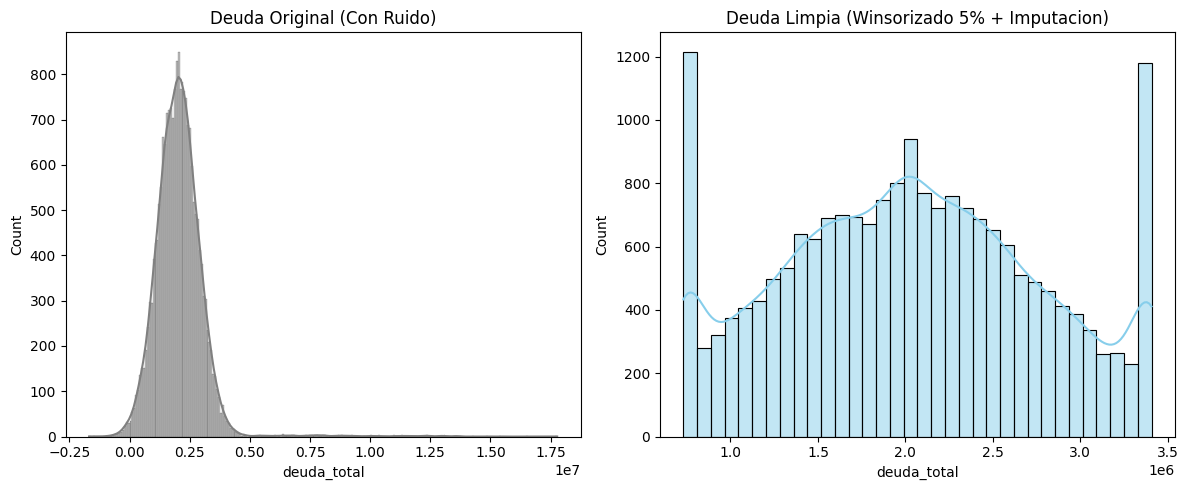

In [588]:
# Comparación rápida de una variable financiera
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data['deuda_total'], kde=True, color='gray')
plt.title('Deuda Original (Con Ruido)')

plt.subplot(1, 2, 2)
sns.histplot(data_clean['deuda_total'], kde=True, color='skyblue')
plt.title('Deuda Limpia (Winsorizado 5% + Imputacion)')

plt.tight_layout()
plt.savefig('deuda_original_limpia.png')
plt.show()

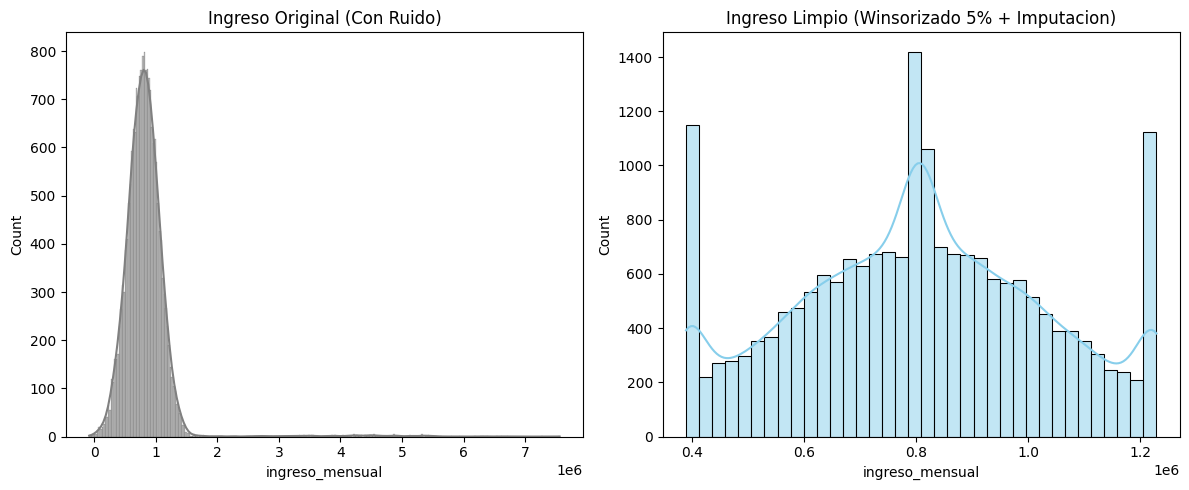

In [589]:
# Comparación rápida de una variable financiera
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data['ingreso_mensual'], kde=True, color='gray')
plt.title('Ingreso Original (Con Ruido)')

plt.subplot(1, 2, 2)
sns.histplot(data_clean['ingreso_mensual'], kde=True, color='skyblue')
plt.title('Ingreso Limpio (Winsorizado 5% + Imputacion)')

plt.tight_layout()
plt.savefig('ingreso_original_limpio.png')
plt.show()

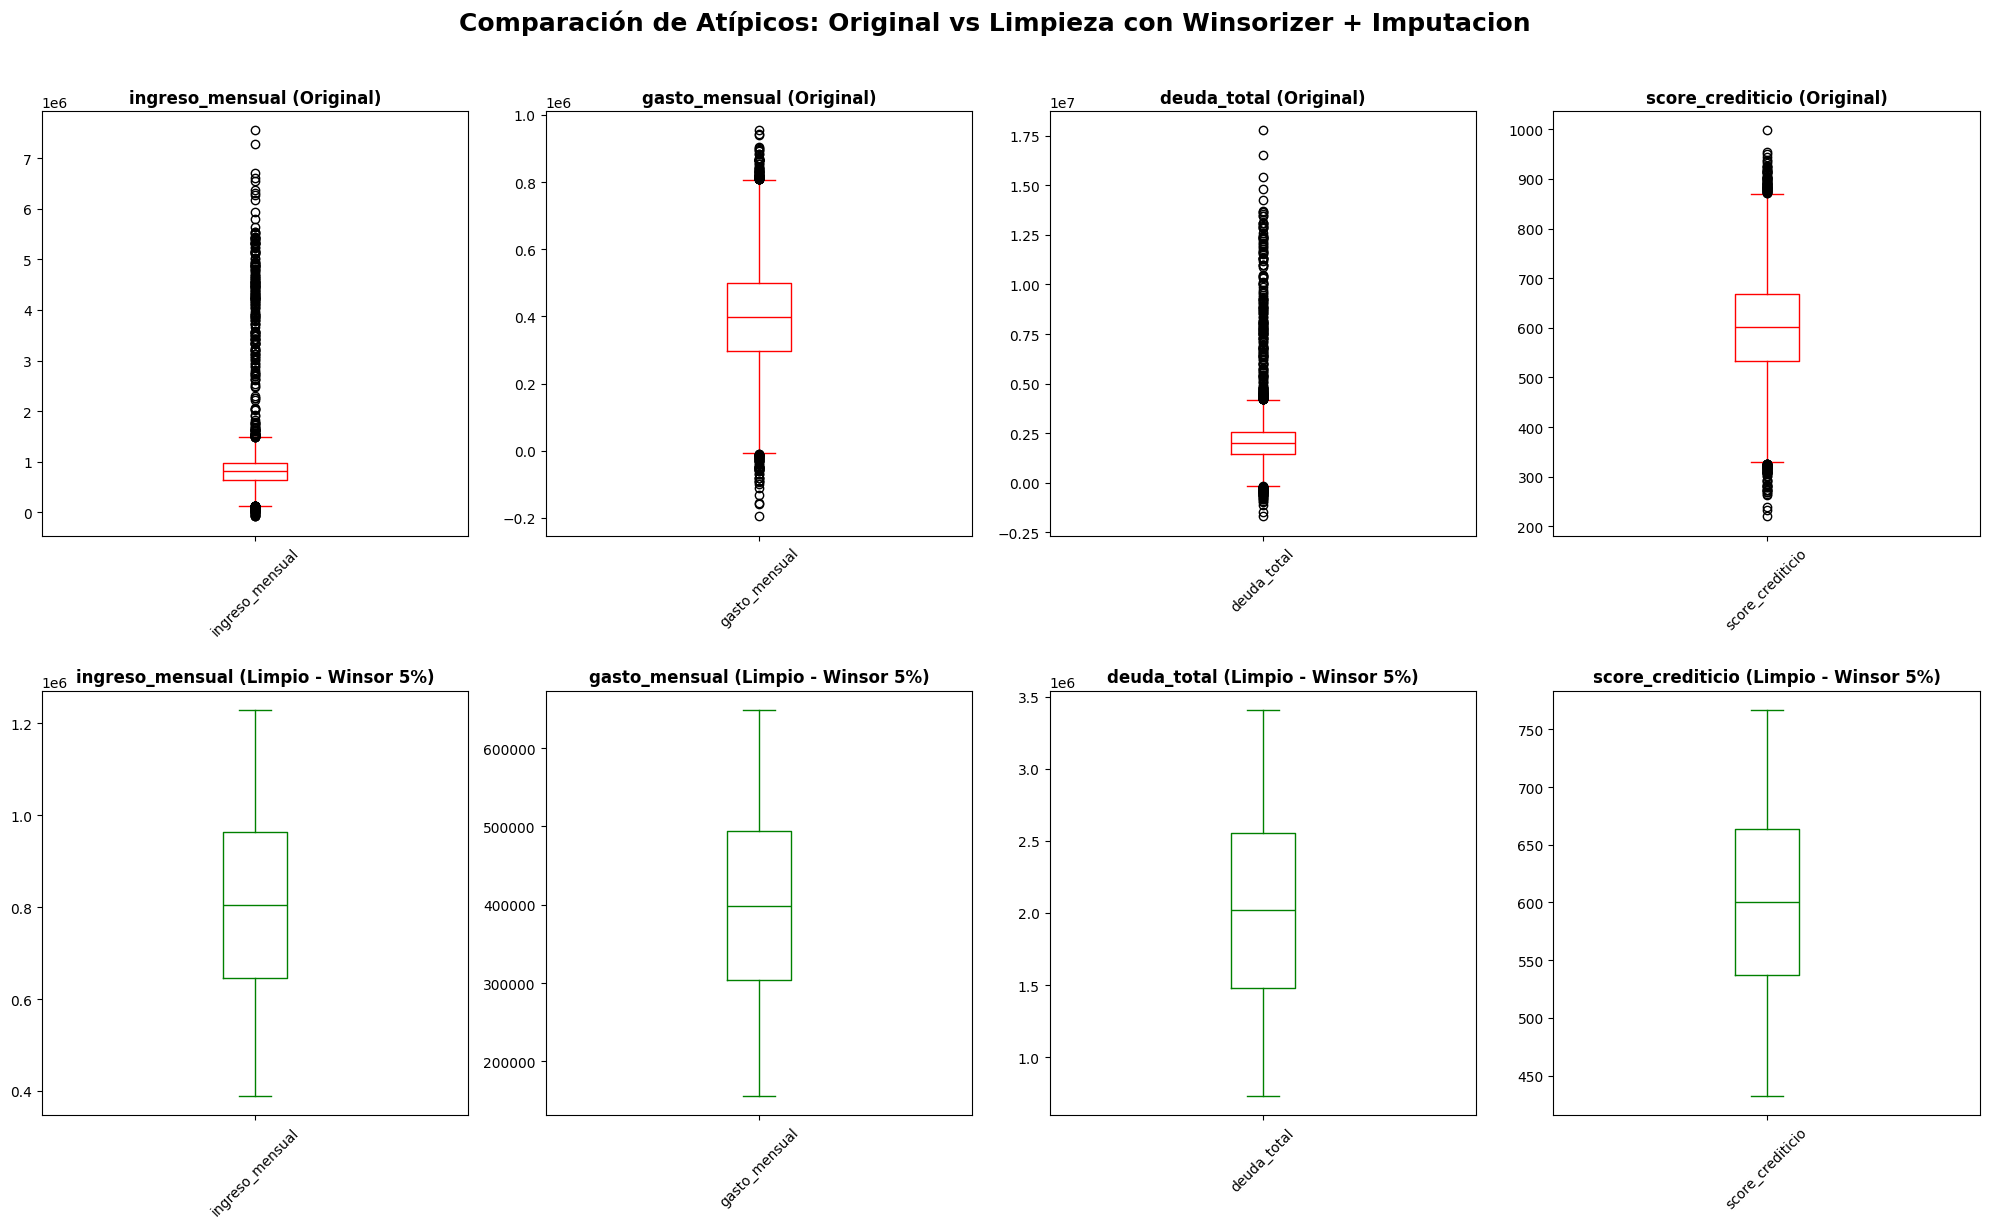

In [590]:
# Definimos las variables a comparar
revision_atipicos = ['ingreso_mensual', 'gasto_mensual', 'deuda_total', 'score_crediticio']

# Creamos una figura con 2 filas (Original vs Limpio) y 4 columnas
fig, axes = plt.subplots(2, 4, figsize=(20, 12))

# Datos Originales (Sin tratar)
for i, col in enumerate(revision_atipicos):
    data[col].plot(kind='box', ax=axes[0, i], color='red')
    axes[0, i].set_title(f'{col} (Original)', fontsize=12, fontweight="bold")
    axes[0, i].tick_params(axis="x", labelrotation=45)

# Datos Limpios (data_clean)
for i, col in enumerate(revision_atipicos):
    data_clean[col].plot(kind='box', ax=axes[1, i], color='green')
    axes[1, i].set_title(f'{col} (Limpio - Winsor 5%)', fontsize=12, fontweight="bold")
    axes[1, i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Comparación de Atípicos: Original vs Limpieza con Winsorizer + Imputacion", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig('comparacion_atipicos_original_limpios.png')
plt.show()

In [591]:
data_clean.describe()

,ingreso_mensual,gasto_mensual,score_crediticio,deuda_total,edad,abandono,antiguedad_meses,frecuencia_compra,ultima_compra_dias
count,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0
mean,805243.855675,400475.754227,600.513001,2030576.108842,48.51485,0.39675,60.2031,9.95675,182.3797
std,224896.415676,133114.968388,89.762466,737351.67283,17.857932,0.489236,34.19241,5.460748,105.02215
min,388783.595781,155678.687984,432.230624,730815.435768,18.0,0.0,1.0,1.0,1.0
25%,645333.781576,304440.76652,537.297541,1481319.039343,33.0,0.0,31.0,5.0,92.0
50%,804195.807327,398843.731235,600.117206,2020483.013848,48.0,0.0,61.0,10.0,181.0
75%,963724.020598,494276.114367,663.982755,2557053.726146,64.0,1.0,90.0,15.0,274.0
max,1229089.269345,648681.57314,766.793418,3407075.255157,79.0,1.0,119.0,19.0,364.0


**Observaciones**:

* **Boxplots (Outliers)** : La aplicación de la técnica de Winsorización al 5% no elimina a los clientes, sino que "suaviza" los valores extremos, manteniendo la representatividad del dato pero reduciendo el ruido para el algoritmo predictivo.

# Realicemos un análisis de correlación


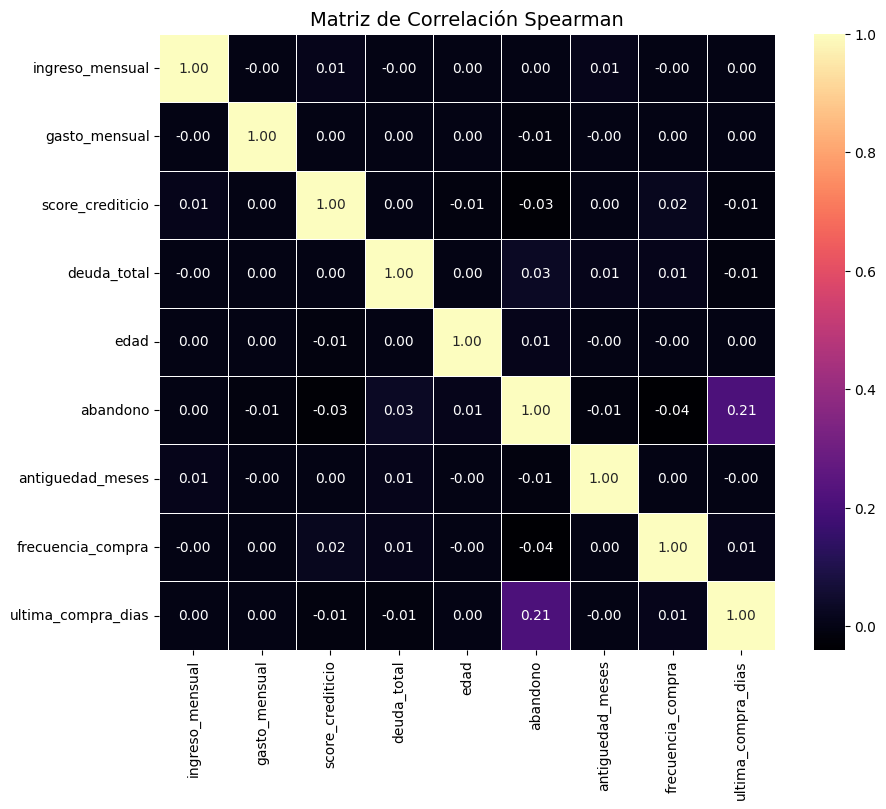

In [592]:
# Seleccionamos los nombres de las columnas numéricas
cols_para_correlacion = data_clean.select_dtypes(include=['number']).columns

# Calculamos la matriz directamente sobre esas columnas
matrix_spearman = data_clean[cols_para_correlacion].corr(method='spearman').round(2)

# Graficar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix_spearman,
    annot=True,
    cmap="magma",
    fmt=".2f",
    square=True,
    linewidths=0.5
)
plt.title("Matriz de Correlación Spearman", fontsize=14)
plt.savefig('Correlacion_spearman.png')
plt.show()

# Fase 2: Transformación de Datos

1. Ingeniería de Características (Feature Engineering)

* Creamos una funcion para poder añadir variables que nos puedan ayudar a identificar porque los clientes dejan la app.

**Justificación de las nuevas variables**

Se crearon variables heurísticas para capturar comportamientos que el modelo no vería por separado:

* **Ratio Deuda/Ingreso**: Estas variables normalizan la situación económica del cliente al calcular qué porcentaje de su ingreso está comprometido. Un ratio elevado es un indicador directo de "estrés financiero", lo que aumenta la probabilidad de que el usuario cancele servicios no esenciales para aliviar su carga económica.
* **Índice de Lealtad**: Al dividir la frecuencia_compra por la antigüedad, normalizamos el comportamiento. Un cliente nuevo con muchas compras es más leal que uno antiguo que compra poco.

* **Riesgo por Inactividad**: Es una variable de castigo ponderado que multiplica los días de ausencia por el inverso de la lealtad. Su lógica permite "perdonar" periodos de inactividad a clientes históricamente fieles, mientras que dispara la alerta de riesgo si el usuario inactivo tiene un historial de bajo compromiso.

In [593]:
# Creamos una copia para no modificar el original
data_copy = data_clean.copy()

def agregar_variables(data : pd.DataFrame):
    """
      Agrega variables al set de datos.
      Parámetros:
        data (pd.DataFrame): Set de datos.
      Retorna:
        pd.DataFrame
    """
    # Ratios Financieros
    data_copy["ratio_deuda"] = data_copy["deuda_total"] / (data_copy["ingreso_mensual"] )
    data_copy["ratio_gasto"] = data_copy["gasto_mensual"] / (data_copy["ingreso_mensual"] )

    # indice de Lealtad (Frecuencia vs Antigüedad)
    data_copy["indice_lealtad"] = data_copy["frecuencia_compra"] / (data_copy["antiguedad_meses"])

    # riesgo_por_inactividad
    data_copy['riesgo_por_inactividad'] = data_copy['ultima_compra_dias'] * (1 / (data_copy['indice_lealtad'] + 1))

    return data_copy

data_copy = agregar_variables(data_copy)


Realizamos una revision

In [594]:

data_copy.head()

,tipo_plan,ingreso_mensual,gasto_mensual,score_crediticio,deuda_total,edad,abandono,antiguedad_meses,frecuencia_compra,ultima_compra_dias,uso_app,ratio_deuda,ratio_gasto,indice_lealtad,riesgo_por_inactividad
0,Estandar,924305.747232,524088.303055,455.40668,2448144.594378,66,1,101,6,356,Bajo,2.648631,0.567008,0.059406,336.037383
1,Premium,1229089.269345,314259.751474,575.048508,1620568.649392,51,0,65,8,307,Medio,1.318512,0.255685,0.123077,273.356164
2,Premium,804195.807327,387192.316142,766.793418,3407075.255157,48,0,1,12,232,Alto,4.236624,0.481465,12.0,17.846154
3,Estandar,436903.213574,417328.601856,442.722671,2999349.527756,54,1,4,3,165,Alto,6.865021,0.955197,0.75,94.285714
4,Estandar,740856.068367,490961.191253,468.188403,1637710.668246,31,1,14,5,283,Bajo,2.210565,0.662694,0.357143,208.526316


# Transformación (escalado y codificación)

In [595]:


# 1. Variables Numericas (Para StandardScaler)
numeric_features = ["edad",
    "ingreso_mensual", "gasto_mensual", "score_crediticio",
    "deuda_total", "antiguedad_meses", "frecuencia_compra",
    "ultima_compra_dias", "ratio_deuda", "ratio_gasto", "indice_lealtad", "riesgo_por_inactividad"
]

# 2. Variables Categoricas (Para OneHotEncoder)
categorical_features = [
    "uso_app"
]

# Uso de StandardScalery OneHotEncoder

**Pipeline de Transformación Estadística**

* **StandardScaler**: Se aplica a las variables numéricas para normalizar su escala (media 0, desviación 1). Esto es crítico porque variables como ingreso_mensual (en millones) podrían "opacar" a la antigüedad (en meses) durante el entrenamiento del modelo.

* **OneHotEncoder**: Transforma variables categóricas en vectores binarios. Se seleccionó sobre el OrdinalEncoder para evitar que el modelo asuma una jerarquía falsa en variables como tipo_plan o uso_app.

In [596]:
# Define el pipeline para las variables cuantitativas
pipeline_numerico = Pipeline(
    steps=[
        ("escalado", StandardScaler())
    ]
)

In [597]:
# Define el pipeline para las variables cualitativas
pipeline_categorico = Pipeline(
    steps=[
        # Acá está lo que había quedado pendiente la semana anterior
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]
)

In [598]:
# Integra ambos pipelines
preprocesador = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, numeric_features),
        ('cat', OneHotEncoder(), categorical_features),
        ("target", "passthrough", ["abandono"])
    ]
)

In [599]:
# Define el pipeline de transformación
pipeline_transformacion = Pipeline(
    steps=[
        ("transformacion", preprocesador)
    ]
)

In [600]:
# Aplica la transformación
data_transformada = pipeline_transformacion.fit_transform(data_copy)

In [601]:
# Crea el Dataframe con los datos limpios
data_transformada = pd.DataFrame(
    pipeline_transformacion.fit_transform(data_copy),
    columns=pipeline_transformacion.named_steps["transformacion"].get_feature_names_out()
)

# Setea el nombre de las columnas
data_transformada.columns = data_transformada.columns.str.replace("num__", "")
data_transformada.columns = data_transformada.columns.str.replace("cat__", "")
data_transformada[numeric_features] = data_transformada[numeric_features].apply(pd.to_numeric)

In [602]:
data_transformada.head()

,edad,ingreso_mensual,gasto_mensual,score_crediticio,deuda_total,antiguedad_meses,frecuencia_compra,ultima_compra_dias,ratio_deuda,ratio_gasto,indice_lealtad,riesgo_por_inactividad,uso_app_Alto,uso_app_Bajo,uso_app_Medio,target__abandono
0,0.979150,0.529421,0.928638,-1.616599,0.566323,1.193186,-0.724598,1.653219,-0.082634,0.083842,-0.303736,2.061422,0.0,1.0,0.0,1.0
1,0.139166,1.884672,-0.647697,-0.283695,-0.556068,0.140295,-0.358339,1.186639,-1.027598,-1.100191,-0.252704,1.379975,0.0,0.0,1.0,0.0
2,-0.028831,-0.004660,-0.099792,1.852496,1.866862,-1.731512,0.374180,0.472486,1.045533,-0.241496,9.266631,-1.397837,1.0,0.0,0.0,0.0
3,0.307163,-1.637864,0.126607,-1.757909,1.313888,-1.643771,-1.273987,-0.165490,2.912840,1.560217,0.249774,-0.566814,1.0,0.0,0.0,1.0
4,-0.980813,-0.286307,0.679771,-1.474201,-0.532819,-1.351302,-0.907728,0.958110,-0.393851,0.447761,-0.065100,0.675168,0.0,1.0,0.0,1.0


In [603]:
data_transformada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   edad                    20000 non-null  float64
 1   ingreso_mensual         20000 non-null  float64
 2   gasto_mensual           20000 non-null  float64
 3   score_crediticio        20000 non-null  float64
 4   deuda_total             20000 non-null  float64
 5   antiguedad_meses        20000 non-null  float64
 6   frecuencia_compra       20000 non-null  float64
 7   ultima_compra_dias      20000 non-null  float64
 8   ratio_deuda             20000 non-null  float64
 9   ratio_gasto             20000 non-null  float64
 10  indice_lealtad          20000 non-null  float64
 11  riesgo_por_inactividad  20000 non-null  float64
 12  uso_app_Alto            20000 non-null  float64
 13  uso_app_Bajo            20000 non-null  float64
 14  uso_app_Medio           20000 non-null

In [604]:
# Exportar el dataset transformado a un archivo CSV
data_transformada.to_csv('dataset_clientes_limpios.csv', index=False)

print("exporteado")

exporteado


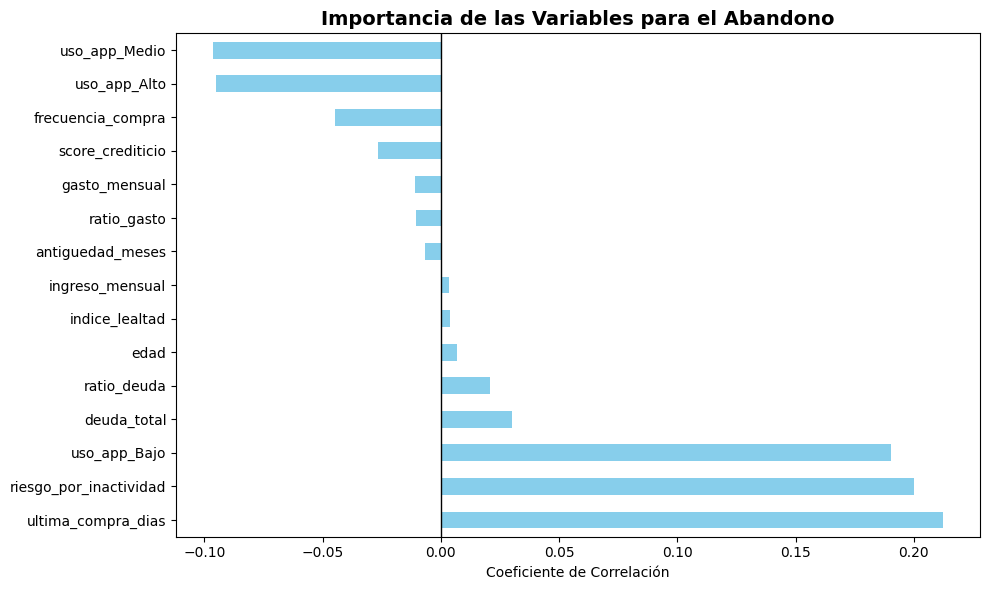

In [605]:
# Gráfico de Impacto en el Abandono (Bar Chart)
corr_matrix = data_transformada.corr()
target_col = 'target__abandono'

if target_col in data_transformada.columns:
    plt.figure(figsize=(10, 6))

    # Extraemos la correlación con el target, ordenamos y quitamos la fila del target mismo
    correlaciones_target = corr_matrix[target_col].sort_values(ascending=False).drop(target_col)

    correlaciones_target.plot(kind='barh', color='skyblue')

    plt.title('Importancia de las Variables para el Abandono', fontsize=14, fontweight="bold")
    plt.xlabel('Coeficiente de Correlación')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Línea en el cero
    plt.tight_layout()

    # Guardar la imagen
    plt.savefig('impacto_variables_abandono.png')
    plt.show()